# Importing Packages #

In [18]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras import regularizers
from keras.layers import Dense, Embedding, LSTM, SpatialDropout1D, Dropout
import pickle

# Loading Dataset #

The GoEmotions dataset was split into three different files. The dataset download steps can be found at: https://github.com/google-research/google-research/tree/master/goemotions/data/full_dataset

This dataset contains around 35k comments from Reddit annotated with an emotion. We need only the six basic emotions, so we comb through the data and filter only the rows that have one of the six basic emotions present.

In [19]:
datapaths = [r"C:\Users\Keanu\Downloads\data\full_dataset\goemotions_1.csv", r"C:\Users\Keanu\Downloads\data\full_dataset\goemotions_2.csv", r"C:\Users\Keanu\Downloads\data\full_dataset\goemotions_3.csv"]

In [20]:
dfs = []

for file in datapaths:
    df = pd.read_csv(file)
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

emotions = ['anger', 'disgust', 'fear', 'joy', 'surprise', 'sadness']

data['emotion'] = None

for index, row in data.iterrows():
    for emotion in emotions:
        if row[emotion] == 1:
            data.at[index, 'emotion'] = emotion

data = data[data['emotion'].isin(emotions)]

In [21]:
data

,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,example_very_unclear,admiration,...,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral,emotion
0,That game hurt.,eew5j0j,Brdd9,nrl,t3_ajis4z,t1_eew18eq,1.548381e+09,1,False,0,...,0,0,0,0,0,0,1,0,0,sadness
13,That is odd.,ee9vw9t,SoloTetherballChamp,jobs,t3_agy1as,t3_agy1as,1.547736e+09,50,False,0,...,0,0,0,0,0,0,0,0,0,disgust
29,So happy for [NAME]. So sad he's not here. Ima...,ee9zjio,YROK1986,DetroitPistons,t3_agty5q,t3_agty5q,1.547739e+09,15,False,0,...,0,0,0,0,0,0,1,0,0,sadness
32,"Dark and funny, but not really nice guy. He ha...",eerqrp7,porky2468,lostredditors,t3_aiy09d,t3_aiy09d,1.548257e+09,61,False,0,...,0,0,0,0,0,0,0,0,0,disgust
43,By far the coolest thing I've seen on this thr...,edm3k6w,W8nd3rW8man,popping,t3_ads2ve,t3_ads2ve,1.547009e+09,78,False,0,...,0,0,0,0,0,0,0,0,0,joy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211187,I just called the Capitol Police. They are not...,ee7fqma,Joyce_III,The_Donald,t3_agn1zp,t3_agn1zp,1.547660e+09,37,False,0,...,0,0,0,0,0,0,0,0,0,anger
211205,I just called the Capitol Police. They are not...,ee7fqma,Joyce_III,The_Donald,t3_agn1zp,t3_agn1zp,1.547660e+09,35,False,0,...,0,0,0,0,0,0,0,0,0,disgust
211212,What a great photo and you two look so happy. 😍,ee0sak1,Kevinc62,gaybros,t3_afpv2x,t3_afpv2x,1.547432e+09,27,False,1,...,0,0,0,0,0,0,0,0,0,joy
211219,"Well, I'm glad you're out of all that now. How...",ed89acy,pompompompi,raisedbynarcissists,t3_ac9etw,t1_ed7gt8x,1.546615e+09,2,False,0,...,0,0,0,0,0,0,0,0,0,joy


# Preprocessing and Tokenizing #

In order to perform sentiment analysis on the text, we need to be able to tokenize the text. We later do save both the model and as well as the tokenizer for loading in the main program.

In [22]:
MAX_NB_WORDS = 50000
MAX_SEQUENCE_LENGTH = 250
EMBEDDING_DIM = 100

In [23]:
emotion_order = ['joy', 'sadness', 'anger', 'fear', 'disgust', 'surprise']

tokenizer = Tokenizer(num_words=MAX_NB_WORDS, filters='!"#$%&()*+,-./:;<=>?@[\]^_`{|}~', lower=True)
tokenizer.fit_on_texts(data['text'].values)
word_index = tokenizer.word_index

X = tokenizer.texts_to_sequences(data['text'].values)
X = pad_sequences(X, maxlen=MAX_SEQUENCE_LENGTH)
print('Shape of data tensor:', X.shape)

Y = pd.get_dummies(data['emotion'])[emotion_order].values
print('Shape of label tensor:', Y.shape)

X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.10, random_state = 0)
print(X_train.shape,Y_train.shape)
print(X_test.shape,Y_test.shape)

Shape of data tensor: (35400, 250)
Shape of label tensor: (35400, 6)
(31860, 250) (31860, 6)
(3540, 250) (3540, 6)


# The Model #

We experimented with creating the model by utilizing different layers and adding more layers. In the end, it was found that using a Long Short Term Memory (LSTM) layer provided the best performance for this text seniment task. 

This first line is commented out but can be used to load the model taht was saved earlier.

In [ ]:
#model = load_model('model_text.keras')

In [14]:
model = Sequential()
model.add(Embedding(MAX_NB_WORDS, EMBEDDING_DIM, input_length=X.shape[1]))
model.add(SpatialDropout1D(0.2))
model.add(LSTM(100, activation='tanh', dropout=0.2, kernel_regularizer=regularizers.l2(0.01)))
model.add(Dropout(0.5))
model.add(Dense(6, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [15]:
model.fit(X_train, Y_train, batch_size=128, epochs=10, validation_data=(X_test, Y_test))

Epoch 1/10
249/249 [==============================] - 20s 41ms/step - loss: 1.9228 - accuracy: 0.2775 - val_loss: 1.5420 - val_accuracy: 0.3958
Epoch 2/10
249/249 [==============================] - 9s 38ms/step - loss: 1.4338 - accuracy: 0.4983 - val_loss: 1.3376 - val_accuracy: 0.5427
Epoch 3/10
249/249 [==============================] - 9s 38ms/step - loss: 1.1544 - accuracy: 0.6126 - val_loss: 1.2236 - val_accuracy: 0.5983
Epoch 4/10
249/249 [==============================] - 9s 38ms/step - loss: 1.0075 - accuracy: 0.6813 - val_loss: 1.1668 - val_accuracy: 0.6226
Epoch 5/10
249/249 [==============================] - 9s 37ms/step - loss: 0.8964 - accuracy: 0.7222 - val_loss: 1.1475 - val_accuracy: 0.6353
Epoch 6/10
249/249 [==============================] - 9s 38ms/step - loss: 0.8216 - accuracy: 0.7451 - val_loss: 1.1507 - val_accuracy: 0.6370
Epoch 7/10
249/249 [==============================] - 9s 37ms/step - loss: 0.7663 - accuracy: 0.7599 - val_loss: 1.1447 - val_accuracy: 0.635

# Results #
We are utilizing a split of the dataset for validation here. As you can see from the confusion matrix, the performance for the model on this set is decent.

111/111 [==============================] - 1s 9ms/step


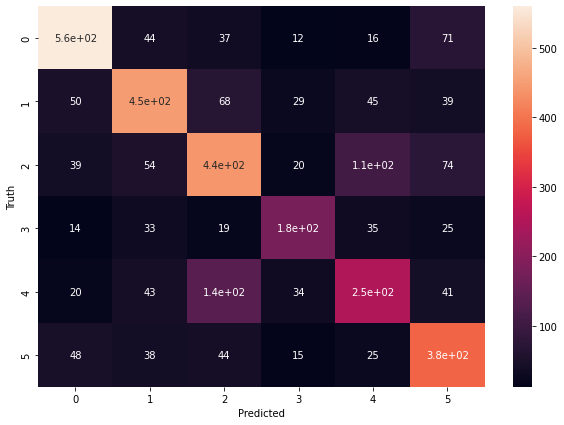

In [55]:
cm = confusion_matrix(np.argmax(Y_test, axis=1), np.argmax(model.predict(X_test), axis=1))
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()

# Saving the Model / Tokenizer #
To be loaded into the main program. We need to not only save the model but also save the tokenizer.

In [57]:
model.save('model_text.keras')

In [25]:
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

# Extra Test Case #
This is how we can test the program with a random string of choice.

In [68]:
def preprocess_text(text):
    # Tokenize the text
    tokenizer = Tokenizer(num_words=50000, filters='!"#$%&()*+,-./:;<=>?@[\]^_`{|}~', lower=True)
    sequence = tokenizer.texts_to_sequences([text])
    
    # Pad the sequence
    padded_sequence = pad_sequences(sequence, maxlen=250)
    
    return padded_sequence

np.argmax(model(preprocess_text("I'm very sad that I could not do this today")), axis=1)

array([2], dtype=int64)

In [71]:
X_test.shape

(3540, 250)

In [72]:
preprocess_text("I'm very sad that I could not do this today").shape

(1, 250)